## Loading the Dataset

The dataset is provided as separate training and testing files.

The training dataset will be used to train the Machine Learning models,
while the testing dataset will be used for evaluating their performance.

Before modelling, both datasets will be inspected to understand their
structure, columns, data types, and missing values.

In [1]:
import pandas as pd

train_df = pd.read_csv("train-data.csv")
test_df = pd.read_csv("test-data.csv")

print("Training data shape:", train_df.shape)
print("Testing data shape:", test_df.shape)

Training data shape: (6019, 14)
Testing data shape: (1234, 13)


In [2]:
train_df.head()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price,Price
0,0,Maruti Wagon R LXI CNG,Mumbai,2010,72000,CNG,Manual,First,26.6 km/kg,998 CC,58.16 bhp,5.0,NaN,1.75
1,1,Hyundai Creta 1.6 CRDi SX Option,Pune,2015,41000,Diesel,Manual,First,19.67 kmpl,1582 CC,126.2 bhp,5.0,NaN,12.50
2,2,Honda Jazz V,Chennai,2011,46000,Petrol,Manual,First,18.2 kmpl,1199 CC,88.7 bhp,5.0,8.61 Lakh,4.50
3,3,Maruti Ertiga VDI,Chennai,2012,87000,Diesel,Manual,First,20.77 kmpl,1248 CC,88.76 bhp,7.0,NaN,6.00
4,4,Audi A4 New 2.0 TDI Multitronic,Coimbatore,2013,40670,Diesel,Automatic,Second,15.2 kmpl,1968 CC,140.8 bhp,5.0,NaN,17.74


In [3]:
test_df.head()

,Unnamed: 0,Name,Location,Year,Kilometers_Driven,Fuel_Type,Transmission,Owner_Type,Mileage,Engine,Power,Seats,New_Price
0,0,Maruti Alto K10 LXI CNG,Delhi,2014,40929,CNG,Manual,First,32.26 km/kg,998 CC,58.2 bhp,4.0,NaN
1,1,Maruti Alto 800 2016-2019 LXI,Coimbatore,2013,54493,Petrol,Manual,Second,24.7 kmpl,796 CC,47.3 bhp,5.0,NaN
2,2,Toyota Innova Crysta Touring Sport 2.4 MT,Mumbai,2017,34000,Diesel,Manual,First,13.68 kmpl,2393 CC,147.8 bhp,7.0,25.27 Lakh
3,3,Toyota Etios Liva GD,Hyderabad,2012,139000,Diesel,Manual,First,23.59 kmpl,1364 CC,null bhp,5.0,NaN
4,4,Hyundai i20 Magna,Mumbai,2014,29000,Petrol,Manual,First,18.5 kmpl,1197 CC,82.85 bhp,5.0,NaN


In [4]:
print("TRAINING DATA")
train_df.info()

print("\nTESTING DATA")
test_df.info()

TRAINING DATA
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 6019 entries, 0 to 6018
Data columns (total 14 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Unnamed: 0         6019 non-null   int64  
 1   Name               6019 non-null   object 
 2   Location           6019 non-null   object 
 3   Year               6019 non-null   int64  
 4   Kilometers_Driven  6019 non-null   int64  
 5   Fuel_Type          6019 non-null   object 
 6   Transmission       6019 non-null   object 
 7   Owner_Type         6019 non-null   object 
 8   Mileage            6017 non-null   object 
 9   Engine             5983 non-null   object 
 10  Power              5983 non-null   object 
 11  Seats              5977 non-null   float64
 12  New_Price          824 non-null    object 
 13  Price              6019 non-null   float64
dtypes: float64(2), int64(3), object(9)
memory usage: 658.5+ KB

TESTING DATA
<class 'pandas.core.frame.DataFra

In [5]:
print("Training columns:")
print(train_df.columns.tolist())

print("\nTesting columns:")
print(test_df.columns.tolist())

Training columns:
['Unnamed: 0', 'Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'New_Price', 'Price']

Testing columns:
['Unnamed: 0', 'Name', 'Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'New_Price']


In [6]:
# Create copies so the original datasets remain unchanged
train = train_df.copy()
test = test_df.copy()

# Remove unnecessary index column
train.drop(columns=["Unnamed: 0"], inplace=True)
test.drop(columns=["Unnamed: 0"], inplace=True)

# Drop New_Price because it has a very large number of missing values
train.drop(columns=["New_Price"], inplace=True)
test.drop(columns=["New_Price"], inplace=True)

print("Training shape:", train.shape)
print("Testing shape:", test.shape)

Training shape: (6019, 12)
Testing shape: (1234, 11)


In [7]:
# Convert Mileage, Engine and Power from text to numeric values

for df in [train, test]:
    df["Mileage"] = (
        df["Mileage"]
        .str.extract(r"([\d.]+)")[0]
        .astype(float)
    )

    df["Engine"] = (
        df["Engine"]
        .str.extract(r"([\d.]+)")[0]
        .astype(float)
    )

    df["Power"] = (
        df["Power"]
        .str.extract(r"([\d.]+)")[0]
        .replace("null", pd.NA)
        .astype(float)
    )

print(train[["Mileage", "Engine", "Power"]].dtypes)

Mileage    float64
Engine     float64
Power      float64
dtype: object


In [8]:
print("Missing values in training data:")
print(train.isnull().sum())

print("\nMissing values in testing data:")
print(test.isnull().sum())

Missing values in training data:
Name                   0
Location               0
Year                   0
Kilometers_Driven      0
Fuel_Type              0
Transmission           0
Owner_Type             0
Mileage                2
Engine                36
Power                143
Seats                 42
Price                  0
dtype: int64

Missing values in testing data:
Name                  0
Location              0
Year                  0
Kilometers_Driven     0
Fuel_Type             0
Transmission          0
Owner_Type            0
Mileage               0
Engine               10
Power                32
Seats                11
dtype: int64


In [9]:
numeric_cols = ["Mileage", "Engine", "Power", "Seats"]

for col in numeric_cols:
    train[col] = train[col].fillna(train[col].median())
    test[col] = test[col].fillna(train[col].median())

print("Remaining missing values:")
print(train.isnull().sum())

Remaining missing values:
Name                 0
Location             0
Year                 0
Kilometers_Driven    0
Fuel_Type            0
Transmission         0
Owner_Type           0
Mileage              0
Engine               0
Power                0
Seats                0
Price                0
dtype: int64


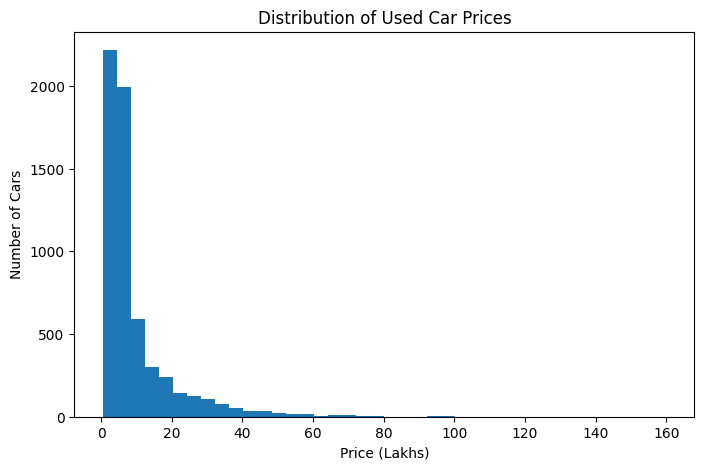

In [10]:
import matplotlib.pyplot as plt

# Price distribution
plt.figure(figsize=(8, 5))
plt.hist(train["Price"], bins=40)
plt.title("Distribution of Used Car Prices")
plt.xlabel("Price (Lakhs)")
plt.ylabel("Number of Cars")
plt.show()

In [11]:
# Price statistics
print(train["Price"].describe())

count    6019.000000
mean        9.479468
std        11.187917
min         0.440000
25%         3.500000
50%         5.640000
75%         9.950000
max       160.000000
Name: Price, dtype: float64


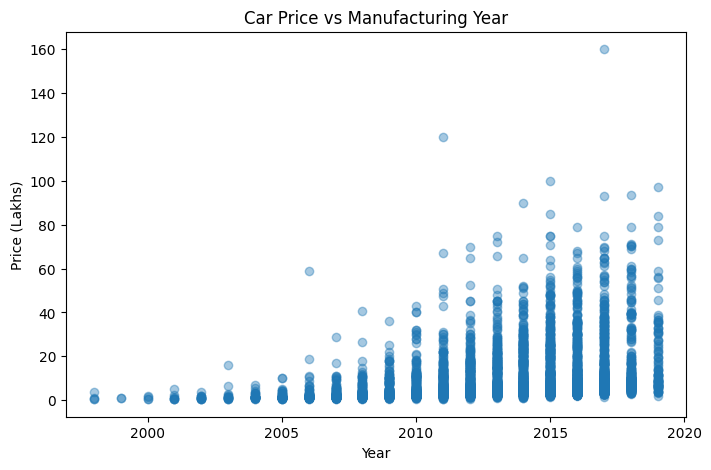

In [12]:
plt.figure(figsize=(8, 5))
plt.scatter(train["Year"], train["Price"], alpha=0.4)
plt.title("Car Price vs Manufacturing Year")
plt.xlabel("Year")
plt.ylabel("Price (Lakhs)")
plt.show()

In [13]:
train.groupby("Fuel_Type")["Price"].mean().sort_values(ascending=False)

Fuel_Type
Electric    12.875000
Diesel      12.840605
Petrol       5.701100
CNG          3.516786
LPG          2.487000
Name: Price, dtype: float64

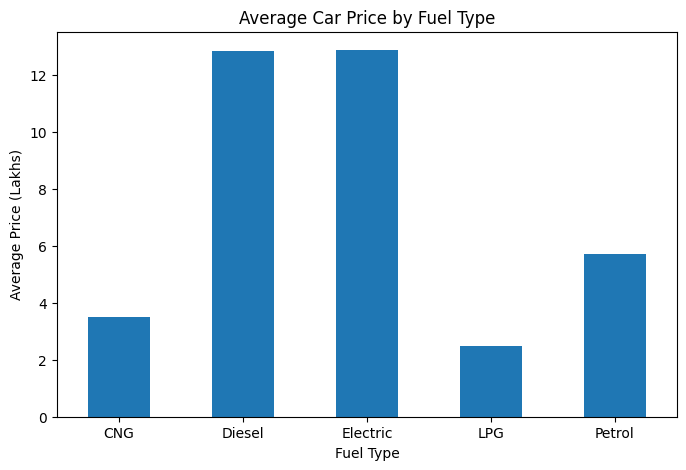

In [14]:
train.groupby("Fuel_Type")["Price"].mean().plot(
    kind="bar",
    figsize=(8, 5)
)

plt.title("Average Car Price by Fuel Type")
plt.xlabel("Fuel Type")
plt.ylabel("Average Price (Lakhs)")
plt.xticks(rotation=0)
plt.show()

In [15]:
train.groupby("Transmission")["Price"].mean().sort_values(ascending=False)

Transmission
Automatic    19.843971
Manual        5.332703
Name: Price, dtype: float64

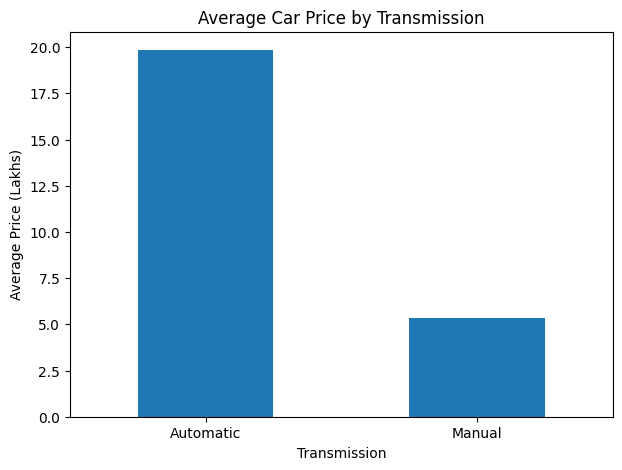

In [16]:
train.groupby("Transmission")["Price"].mean().plot(
    kind="bar",
    figsize=(7, 5)
)

plt.title("Average Car Price by Transmission")
plt.xlabel("Transmission")
plt.ylabel("Average Price (Lakhs)")
plt.xticks(rotation=0)
plt.show()

In [17]:
numeric_cols = [
    "Year",
    "Kilometers_Driven",
    "Mileage",
    "Engine",
    "Power",
    "Seats",
    "Price"
]

print(train[numeric_cols].corr()["Price"].sort_values(ascending=False))

Price                1.000000
Power                0.769711
Engine               0.657347
Year                 0.305327
Seats                0.052811
Kilometers_Driven   -0.011493
Mileage             -0.306588
Name: Price, dtype: float64


In [18]:
# Create car age feature
CURRENT_YEAR = 2025

train["Car_Age"] = CURRENT_YEAR - train["Year"]
test["Car_Age"] = CURRENT_YEAR - test["Year"]

print(train[["Year", "Car_Age"]].head())

   Year  Car_Age
0  2010       15
1  2015       10
2  2011       14
3  2012       13
4  2013       12


In [19]:
# Extract car brand from Name
train["Brand"] = train["Name"].str.split().str[0]
test["Brand"] = test["Name"].str.split().str[0]

print(train[["Name", "Brand"]].head(10))

                                  Name       Brand
0               Maruti Wagon R LXI CNG      Maruti
1     Hyundai Creta 1.6 CRDi SX Option     Hyundai
2                         Honda Jazz V       Honda
3                    Maruti Ertiga VDI      Maruti
4      Audi A4 New 2.0 TDI Multitronic        Audi
5      Hyundai EON LPG Era Plus Option     Hyundai
6               Nissan Micra Diesel XV      Nissan
7    Toyota Innova Crysta 2.8 GX AT 8S      Toyota
8  Volkswagen Vento Diesel Comfortline  Volkswagen
9       Tata Indica Vista Quadrajet LS        Tata


In [20]:
train.drop(columns=["Name"], inplace=True)
test.drop(columns=["Name"], inplace=True)

In [21]:
print("Training columns:")
print(train.columns.tolist())

print("\nTesting columns:")
print(test.columns.tolist())

Training columns:
['Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'Price', 'Car_Age', 'Brand']

Testing columns:
['Location', 'Year', 'Kilometers_Driven', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Mileage', 'Engine', 'Power', 'Seats', 'Car_Age', 'Brand']


In [22]:
y = train["Price"]

In [23]:
X_test_final = test.copy()

In [24]:
X = train.drop(columns=["Price"])
y = train["Price"]

print("Features shape:", X.shape)
print("Target shape:", y.shape)

Features shape: (6019, 12)
Target shape: (6019,)


In [25]:
from sklearn.model_selection import train_test_split

X_train, X_val, y_train, y_val = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42
)

print("Training samples:", X_train.shape[0])
print("Validation samples:", X_val.shape[0])

Training samples: 4815
Validation samples: 1204


In [26]:
from sklearn.compose import ColumnTransformer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

numeric_features = X.select_dtypes(
    include=["int64", "float64"]
).columns.tolist()

categorical_features = X.select_dtypes(
    include=["object"]
).columns.tolist()

print("Numerical features:", numeric_features)
print("Categorical features:", categorical_features)

Numerical features: ['Year', 'Kilometers_Driven', 'Mileage', 'Engine', 'Power', 'Seats', 'Car_Age']
Categorical features: ['Location', 'Fuel_Type', 'Transmission', 'Owner_Type', 'Brand']


In [27]:
preprocessor = ColumnTransformer(
    transformers=[
        (
            "num",
            StandardScaler(),
            numeric_features
        ),
        (
            "cat",
            OneHotEncoder(
                handle_unknown="ignore"
            ),
            categorical_features
        )
    ]
)

In [28]:
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LinearRegression

linear_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", LinearRegression())
    ]
)

linear_model.fit(X_train, y_train)

linear_pred = linear_model.predict(X_val)

In [29]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

linear_mae = mean_absolute_error(y_val, linear_pred)
linear_rmse = np.sqrt(mean_squared_error(y_val, linear_pred))
linear_r2 = r2_score(y_val, linear_pred)

print("Linear Regression")
print("MAE:", linear_mae)
print("RMSE:", linear_rmse)
print("R²:", linear_r2)

Linear Regression
MAE: 3.115069965735838
RMSE: 7.19170829962008
R²: 0.5797100453519044


In [30]:
from sklearn.ensemble import RandomForestRegressor

rf_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "model",
            RandomForestRegressor(
                n_estimators=300,
                random_state=42,
                n_jobs=-1
            )
        )
    ]
)

rf_model.fit(X_train, y_train)

rf_pred = rf_model.predict(X_val)

In [31]:
rf_mae = mean_absolute_error(y_val, rf_pred)
rf_rmse = np.sqrt(mean_squared_error(y_val, rf_pred))
rf_r2 = r2_score(y_val, rf_pred)

print("Random Forest")
print("MAE:", rf_mae)
print("RMSE:", rf_rmse)
print("R²:", rf_r2)

Random Forest
MAE: 1.4790694416758954
RMSE: 3.600711585442721
R²: 0.8946434466608224


In [32]:
from sklearn.ensemble import GradientBoostingRegressor

gb_model = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        (
            "model",
            GradientBoostingRegressor(
                n_estimators=200,
                learning_rate=0.05,
                max_depth=3,
                random_state=42
            )
        )
    ]
)

gb_model.fit(X_train, y_train)

gb_pred = gb_model.predict(X_val)

In [33]:
gb_mae = mean_absolute_error(y_val, gb_pred)
gb_rmse = np.sqrt(mean_squared_error(y_val, gb_pred))
gb_r2 = r2_score(y_val, gb_pred)

print("Gradient Boosting")
print("MAE:", gb_mae)
print("RMSE:", gb_rmse)
print("R²:", gb_r2)

Gradient Boosting
MAE: 1.748438442259393
RMSE: 3.7827366617848908
R²: 0.8837221214530432


In [34]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

results.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
1,Random Forest,1.479069,3.600712,0.894643
2,Gradient Boosting,1.748438,3.782737,0.883722
0,Linear Regression,3.115070,7.191708,0.579710


In [35]:
results = pd.DataFrame({
    "Model": [
        "Linear Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "MAE": [
        linear_mae,
        rf_mae,
        gb_mae
    ],
    "RMSE": [
        linear_rmse,
        rf_rmse,
        gb_rmse
    ],
    "R2": [
        linear_r2,
        rf_r2,
        gb_r2
    ]
})

results.sort_values("R2", ascending=False)

,Model,MAE,RMSE,R2
1,Random Forest,1.479069,3.600712,0.894643
2,Gradient Boosting,1.748438,3.782737,0.883722
0,Linear Regression,3.115070,7.191708,0.579710


In [36]:
# Select Random Forest as the final model

final_model = rf_model

print("Final model selected: Random Forest")

Final model selected: Random Forest


In [37]:
# Train final model on the complete training dataset

final_model.fit(X, y)

print("Final Random Forest model trained successfully!")

Final Random Forest model trained successfully!


In [38]:
# Generate predictions for the provided test dataset

test_predictions = final_model.predict(test)

print("Predictions generated:", len(test_predictions))
print("First 10 predictions:")
print(test_predictions[:10])

Predictions generated: 1234
First 10 predictions:
[ 3.26113333  2.93853333 17.31906667  3.92343333  4.62283333 12.42253333
 21.34116667  2.20956667  3.73446667 10.47843333]


In [39]:
# Create submission/prediction file

predictions_df = pd.DataFrame({
    "Price": test_predictions
})

predictions_df.to_csv(
    "used_car_price_predictions.csv",
    index=False
)

print("Prediction file saved successfully!")

Prediction file saved successfully!


In [40]:
predictions_df.head(10)

,Price
0,3.261133
1,2.938533
2,17.319067
3,3.923433
4,4.622833
5,12.422533
6,21.341167
7,2.209567
8,3.734467
9,10.478433


In [41]:
# Get feature names after preprocessing
feature_names = final_model.named_steps["preprocessing"].get_feature_names_out()

# Get Random Forest feature importances
importances = final_model.named_steps["model"].feature_importances_

feature_importance = pd.DataFrame({
    "Feature": feature_names,
    "Importance": importances
}).sort_values("Importance", ascending=False)

feature_importance.head(15)

,Feature,Importance
4,num__Power,0.651130
0,num__Year,0.080562
6,num__Car_Age,0.078988
1,num__Kilometers_Driven,0.044436
3,num__Engine,0.039223
45,cat__Brand_Land,0.022585
2,num__Mileage,0.018982
5,num__Seats,0.007349
12,cat__Location_Hyderabad,0.007109
48,cat__Brand_Mercedes-Benz,0.005700


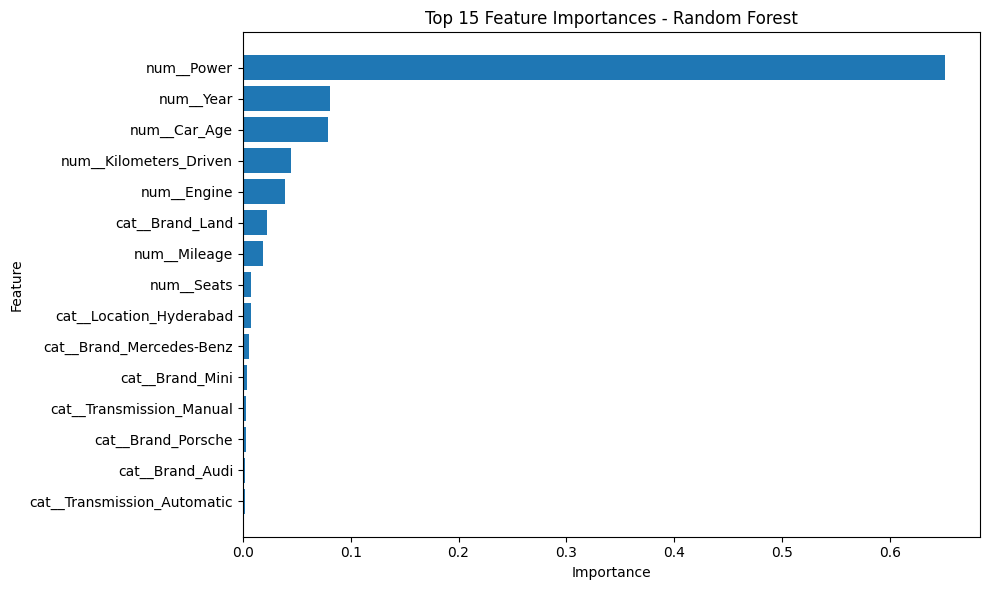

In [42]:
plt.figure(figsize=(10, 6))

top_features = feature_importance.head(15).sort_values("Importance")

plt.barh(
    top_features["Feature"],
    top_features["Importance"]
)

plt.title("Top 15 Feature Importances - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")

plt.tight_layout()
plt.show()

In [43]:
import joblib

joblib.dump(
    final_model,
    "used_car_price_model.joblib"
)

print("Model saved successfully!")

Model saved successfully!


In [44]:
import os

print(
    "Model file exists:",
    os.path.exists("used_car_price_model.joblib")
)

Model file exists: True


In [45]:
print("Prediction file shape:", predictions_df.shape)
print(predictions_df.head(10))

Prediction file shape: (1234, 1)
       Price
0   3.261133
1   2.938533
2  17.319067
3   3.923433
4   4.622833
5  12.422533
6  21.341167
7   2.209567
8   3.734467
9  10.478433
